## Análise Exploratória de Dados

In [1]:
#Importações
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from Apoio.config import DADOS_CONSOLIDADOS, DADOS_TRATADOS

sns.set_theme(palette="bright")

#### Importação da base e checagens básicas

In [2]:
df = pd.read_parquet(DADOS_CONSOLIDADOS)

df.head()

,ano_modelo,marca,modelo,classe_veiculo,tamanho_motor_l,cilindros,transmissao,tipo_combustivel,consumo_cidade_l_100km,consumo_estrada_l_100km,consumo_combinado_l_100km,consumo_combinado_mpg,emissoes_co2_g_km,classificacao_co2,classificacao_smog
0,2005,Acura,1.7EL,Compact,1.7,4,A4,X,9.2,7.2,8.3,34,191,NaN,NaN
1,2005,Acura,1.7EL,Compact,1.7,4,M5,X,9.1,7.3,8.3,34,191,NaN,NaN
2,2005,Acura,MDX AWD,Sport utility vehicle,3.5,6,A5,Z,15.9,11.1,13.7,21,315,NaN,NaN
3,2005,Acura,NSX,Two-seater,3.0,6,AS4,Z,15.1,10.5,13.0,22,299,NaN,NaN
4,2005,Acura,NSX,Two-seater,3.2,6,M6,Z,15.1,10.5,13.0,22,299,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20521 entries, 0 to 20520
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ano_modelo                 20521 non-null  int64  
 1   marca                      20521 non-null  object 
 2   modelo                     20521 non-null  object 
 3   classe_veiculo             20521 non-null  object 
 4   tamanho_motor_l            20521 non-null  float64
 5   cilindros                  20521 non-null  int64  
 6   transmissao                20521 non-null  object 
 7   tipo_combustivel           20521 non-null  object 
 8   consumo_cidade_l_100km     20521 non-null  float64
 9   consumo_estrada_l_100km    20521 non-null  float64
 10  consumo_combinado_l_100km  20521 non-null  float64
 11  consumo_combinado_mpg      20521 non-null  int64  
 12  emissoes_co2_g_km          20521 non-null  int64  
 13  classificacao_co2          8832 non-null   flo

In [4]:
with pd.option_context("display.float_format", "{:.2f}".format):
    display(df.describe())

,ano_modelo,tamanho_motor_l,cilindros,consumo_cidade_l_100km,consumo_estrada_l_100km,consumo_combinado_l_100km,consumo_combinado_mpg,emissoes_co2_g_km,classificacao_co2,classificacao_smog
count,20521.00,20521.00,20521.00,20521.00,20521.00,20521.00,20521.00,20521.00,8832.00,7726.00
mean,2014.24,3.34,5.83,13.44,9.72,11.76,25.74,266.81,4.63,4.82
std,5.59,1.35,1.87,3.78,2.52,3.18,7.02,63.51,1.58,1.79
min,2005.00,0.80,2.00,4.00,3.90,4.00,11.00,94.00,1.00,1.00
25%,2009.00,2.20,4.00,10.80,8.00,9.60,21.00,221.00,4.00,3.00
50%,2014.00,3.00,6.00,13.00,9.30,11.30,25.00,262.00,5.00,5.00
75%,2019.00,4.00,8.00,15.50,11.00,13.40,29.00,304.00,5.00,6.00
max,2024.00,8.40,16.00,30.70,22.10,26.10,71.00,608.00,10.00,8.00


In [5]:
df.describe(exclude="number")

,marca,modelo,classe_veiculo,transmissao,tipo_combustivel
count,20521,20521,20521,20521,20521
unique,48,3522,17,29,5
top,Chevrolet,Mustang,Mid-size,AS6,X
freq,1884,96,2736,2876,10179


#### Criando uma nova coluna para o número de marchas e eliminando da coluna de transmissão

In [6]:
df["marchas"] = df["transmissao"].str.extract(r"(\d+)").astype("float")
df["transmissao"] = df["transmissao"].str.replace(r"(\d+)", "", regex=True)

df.head()

,ano_modelo,marca,modelo,classe_veiculo,tamanho_motor_l,cilindros,transmissao,tipo_combustivel,consumo_cidade_l_100km,consumo_estrada_l_100km,consumo_combinado_l_100km,consumo_combinado_mpg,emissoes_co2_g_km,classificacao_co2,classificacao_smog,marchas
0,2005,Acura,1.7EL,Compact,1.7,4,A,X,9.2,7.2,8.3,34,191,NaN,NaN,4.0
1,2005,Acura,1.7EL,Compact,1.7,4,M,X,9.1,7.3,8.3,34,191,NaN,NaN,5.0
2,2005,Acura,MDX AWD,Sport utility vehicle,3.5,6,A,Z,15.9,11.1,13.7,21,315,NaN,NaN,5.0
3,2005,Acura,NSX,Two-seater,3.0,6,AS,Z,15.1,10.5,13.0,22,299,NaN,NaN,4.0
4,2005,Acura,NSX,Two-seater,3.2,6,M,Z,15.1,10.5,13.0,22,299,NaN,NaN,6.0


#### Substituindo a informação de tipo_combustivel por seu significado

In [7]:
comb = {
    "X": "gasolina_regular",
    "Z": "gasolina_premium",
    "D": "diesel",
    "E": "etanol",
    "N": "gas_natural"
}

df["tipo_combustivel"] = df["tipo_combustivel"].map(comb)

df.head()

,ano_modelo,marca,modelo,classe_veiculo,tamanho_motor_l,cilindros,transmissao,tipo_combustivel,consumo_cidade_l_100km,consumo_estrada_l_100km,consumo_combinado_l_100km,consumo_combinado_mpg,emissoes_co2_g_km,classificacao_co2,classificacao_smog,marchas
0,2005,Acura,1.7EL,Compact,1.7,4,A,gasolina_regular,9.2,7.2,8.3,34,191,NaN,NaN,4.0
1,2005,Acura,1.7EL,Compact,1.7,4,M,gasolina_regular,9.1,7.3,8.3,34,191,NaN,NaN,5.0
2,2005,Acura,MDX AWD,Sport utility vehicle,3.5,6,A,gasolina_premium,15.9,11.1,13.7,21,315,NaN,NaN,5.0
3,2005,Acura,NSX,Two-seater,3.0,6,AS,gasolina_premium,15.1,10.5,13.0,22,299,NaN,NaN,4.0
4,2005,Acura,NSX,Two-seater,3.2,6,M,gasolina_premium,15.1,10.5,13.0,22,299,NaN,NaN,6.0


#### Verificando se há colunas com valores zeros, nulos ou duplicados

In [8]:
df[df == 0].count()

ano_modelo                   0
marca                        0
modelo                       0
classe_veiculo               0
tamanho_motor_l              0
cilindros                    0
transmissao                  0
tipo_combustivel             0
consumo_cidade_l_100km       0
consumo_estrada_l_100km      0
consumo_combinado_l_100km    0
consumo_combinado_mpg        0
emissoes_co2_g_km            0
classificacao_co2            0
classificacao_smog           0
marchas                      0
dtype: int64

In [9]:
df.isnull().sum()

ano_modelo                       0
marca                            0
modelo                           0
classe_veiculo                   0
tamanho_motor_l                  0
cilindros                        0
transmissao                      0
tipo_combustivel                 0
consumo_cidade_l_100km           0
consumo_estrada_l_100km          0
consumo_combinado_l_100km        0
consumo_combinado_mpg            0
emissoes_co2_g_km                0
classificacao_co2            11689
classificacao_smog           12795
marchas                        864
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

Com isso, podemos observar que as colunas de **"classificacao_co2"**, **"classificacao_smog"** e **"marchas"** possuem valores nulos

| Coluna                        | Quantidade                  |
| ----------------------------- | --------------------------- |
| `classificacao_co2`           | `11689`                     |
| `classificacao_smog`          | `12795`                     |
| `marchas`                     | `864`                       |

#### Eliminando as colunas "consumo_combinado_mpg" e "modelo"

A coluna **consumo_combinado_mpg** é a **consumo_combinado_l_100km**, mas convertida para milhas.

Já a coluna **modelo** deve ser eliminada, pois possui `3522` valores únicos e isso pode atrapalhar o algortimo na identificação de valores que só aparecem apenas uma vez.

In [11]:
df = df.drop(columns=["consumo_combinado_mpg", "modelo"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20521 entries, 0 to 20520
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ano_modelo                 20521 non-null  int64  
 1   marca                      20521 non-null  object 
 2   classe_veiculo             20521 non-null  object 
 3   tamanho_motor_l            20521 non-null  float64
 4   cilindros                  20521 non-null  int64  
 5   transmissao                20521 non-null  object 
 6   tipo_combustivel           20521 non-null  object 
 7   consumo_cidade_l_100km     20521 non-null  float64
 8   consumo_estrada_l_100km    20521 non-null  float64
 9   consumo_combinado_l_100km  20521 non-null  float64
 10  emissoes_co2_g_km          20521 non-null  int64  
 11  classificacao_co2          8832 non-null   float64
 12  classificacao_smog         7726 non-null   float64
 13  marchas                    19657 non-null  flo

In [12]:
df.nunique()

ano_modelo                    20
marca                         48
classe_veiculo                17
tamanho_motor_l               61
cilindros                      9
transmissao                    5
tipo_combustivel               5
consumo_cidade_l_100km       237
consumo_estrada_l_100km      168
consumo_combinado_l_100km    207
emissoes_co2_g_km            374
classificacao_co2             10
classificacao_smog             7
marchas                        8
dtype: int64

#### Criando uma lista de colunas categóricas, para visualização

In [13]:
categoricas = df.select_dtypes(include="object").columns
categoricas = categoricas.to_list()
categoricas.extend(["ano_modelo", "cilindros", "marchas"])
categoricas

['marca',
 'classe_veiculo',
 'transmissao',
 'tipo_combustivel',
 'ano_modelo',
 'cilindros',
 'marchas']

As colunas **ano_modelo**, **cilindros** e **marchas** foram adicionadas, pois possuem caráter categórico.

#### Gráfico de contagem das colunas categóricas

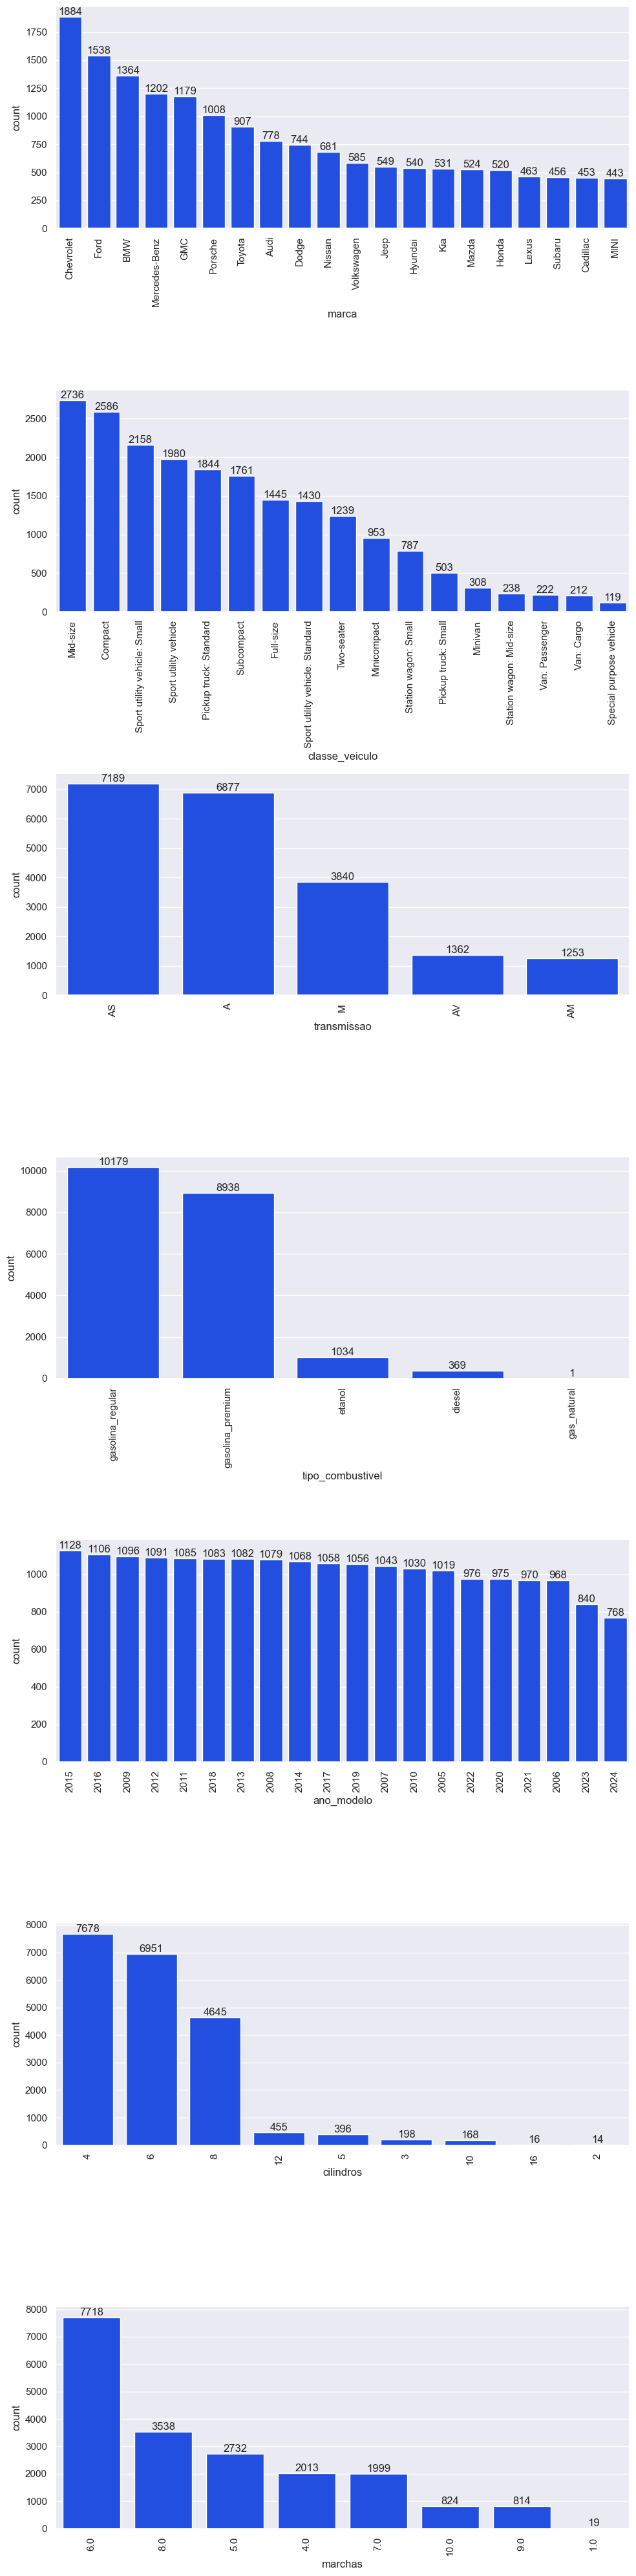

In [14]:
fig, axs = plt.subplots(7, 1, figsize=(10, 40))

for ax, coluna in zip(axs.flatten(), categoricas):
    sns.countplot(data=df, x=coluna, ax=ax, order=df[coluna].value_counts().index[:20])
    
    ax.bar_label(ax.containers[0])
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

#### Criando um crosstab entre as colunas de marcha e transmissão, para verificar a frequência e relação entre elas

In [15]:
pd.crosstab(df["marchas"], df["transmissao"], dropna=False)

transmissao,A,AM,AS,AV,M
marchas,,,,,
1.0,0,0,0,19,0
4.0,1850,0,162,0,1
5.0,889,6,673,0,1164
6.0,1944,215,2876,159,2524
7.0,276,794,621,157,151
8.0,989,232,2193,124,0
9.0,650,6,158,0,0
10.0,279,0,506,39,0
NaN,0,0,0,864,0


#### Criando os histogramas e boxplots das colunas numéricas

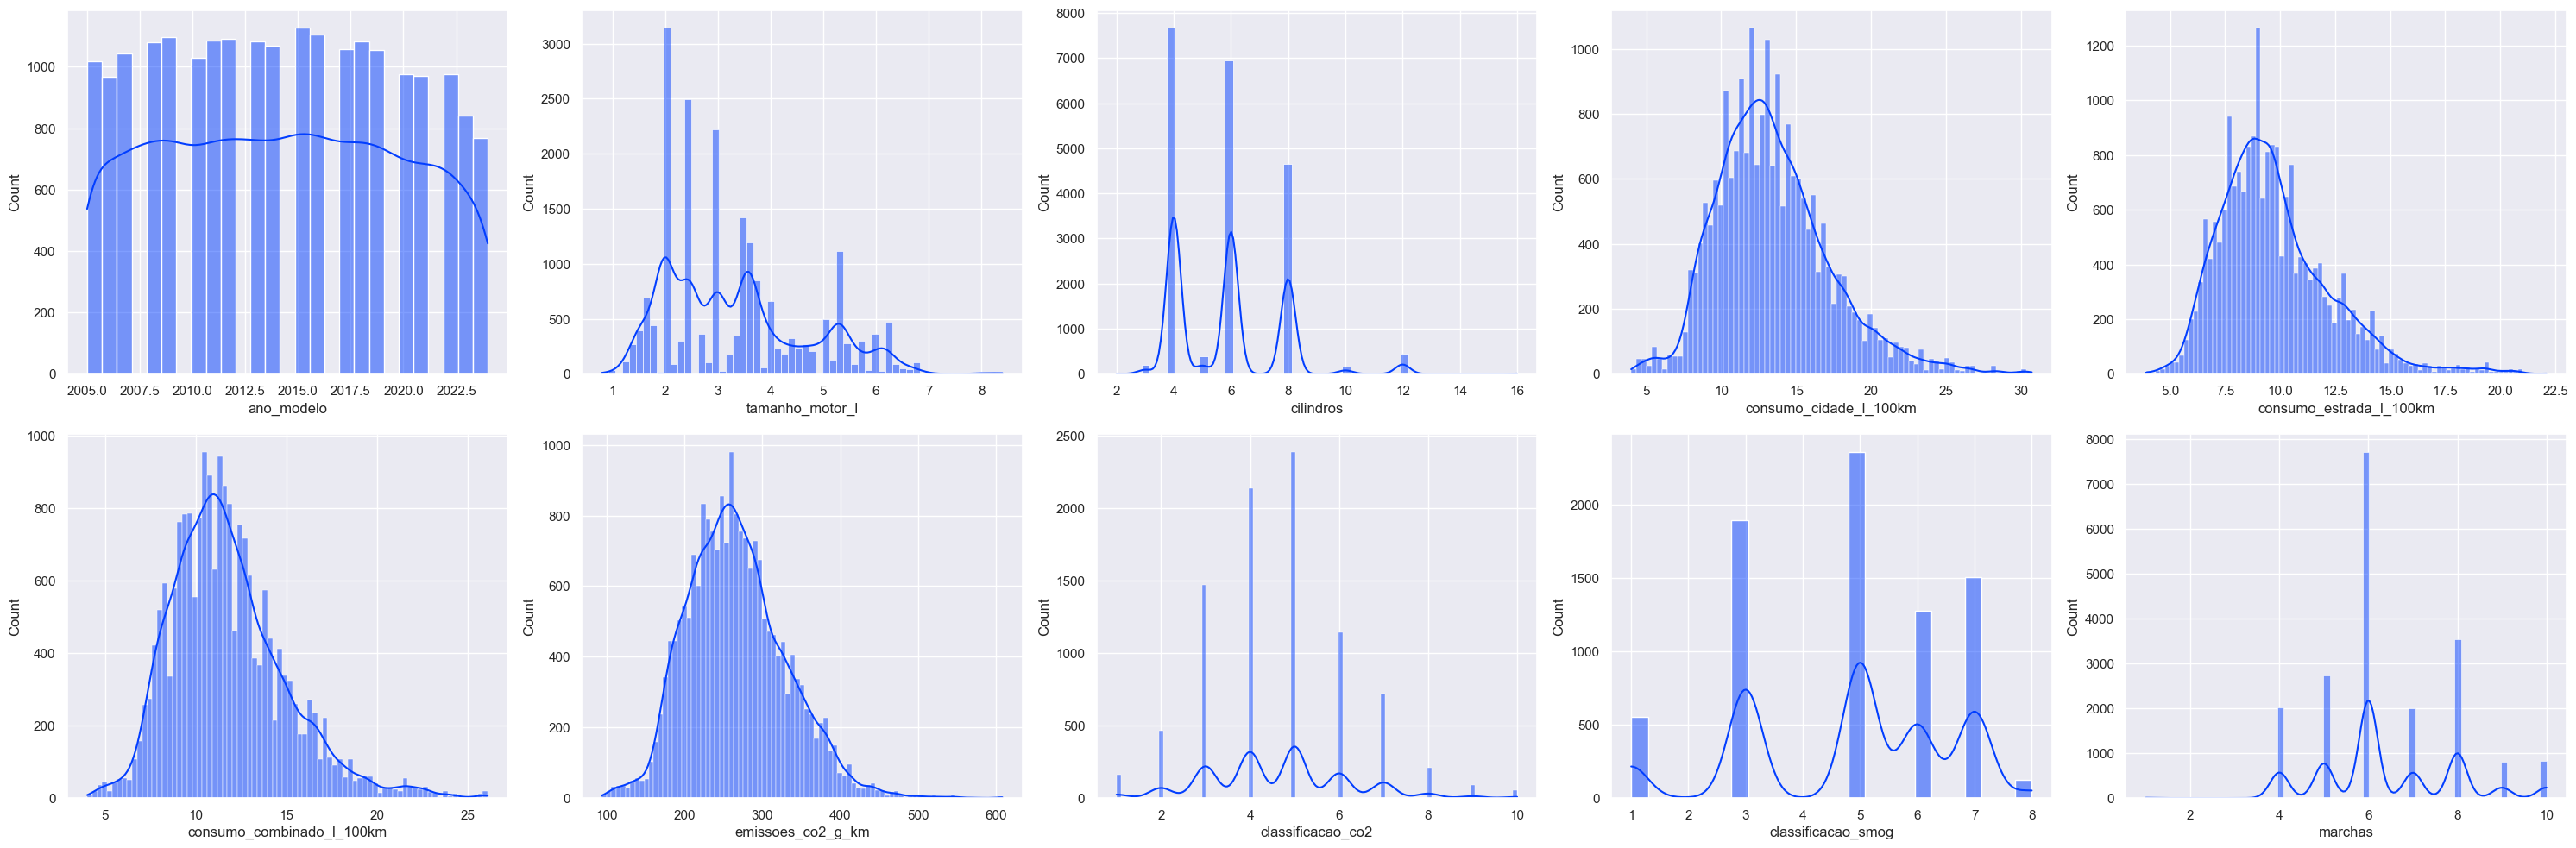

In [16]:
fig, axs = plt.subplots(2, 5, figsize=(30, 10))

for ax, coluna in zip(axs.flatten(), df.select_dtypes("number").columns):
    sns.histplot(data=df, x=coluna, ax=ax, kde=True)

plt.tight_layout()
plt.show()

**Analisando cada histograma:**

- `ano_modelo`: distribuição aproximadamente uniforme, com pequenas variações na frequência entre os anos.
- `tamanho_motor_l`: distribuição assimétrica à direita, com maior concentração em motores menores e cauda para valores maiores.
- `cilindros`: distribuição discreta e multimodal, com forte concentração em 4, 6 e 8 cilindros.
- `consumo_cidade_l_100km`: distribuição assimétrica à direita, com cauda prolongada para maiores valores de consumo.
- `consumo_estrada_l_100km`: distribuição assimétrica à direita, com concentração em valores menores e cauda para maiores consumos.
- `consumo_combinado_l_100km`: distribuição assimétrica à direita, com concentração em valores menores e cauda prolongada para maiores consumos.
- `emissoes_co2_g_km`: distribuição assimétrica à direita, com cauda prolongada para valores elevados de emissão.
- `classificacao_co2`: distribuição discreta e multimodal, com concentração em determinadas categorias.
- `classificacao_smog`: distribuição discreta e multimodal, com concentração em determinadas categorias.
- `marchas`: distribuição discreta e multimodal, com forte concentração em 4, 5 e principalmente 6 marchas.

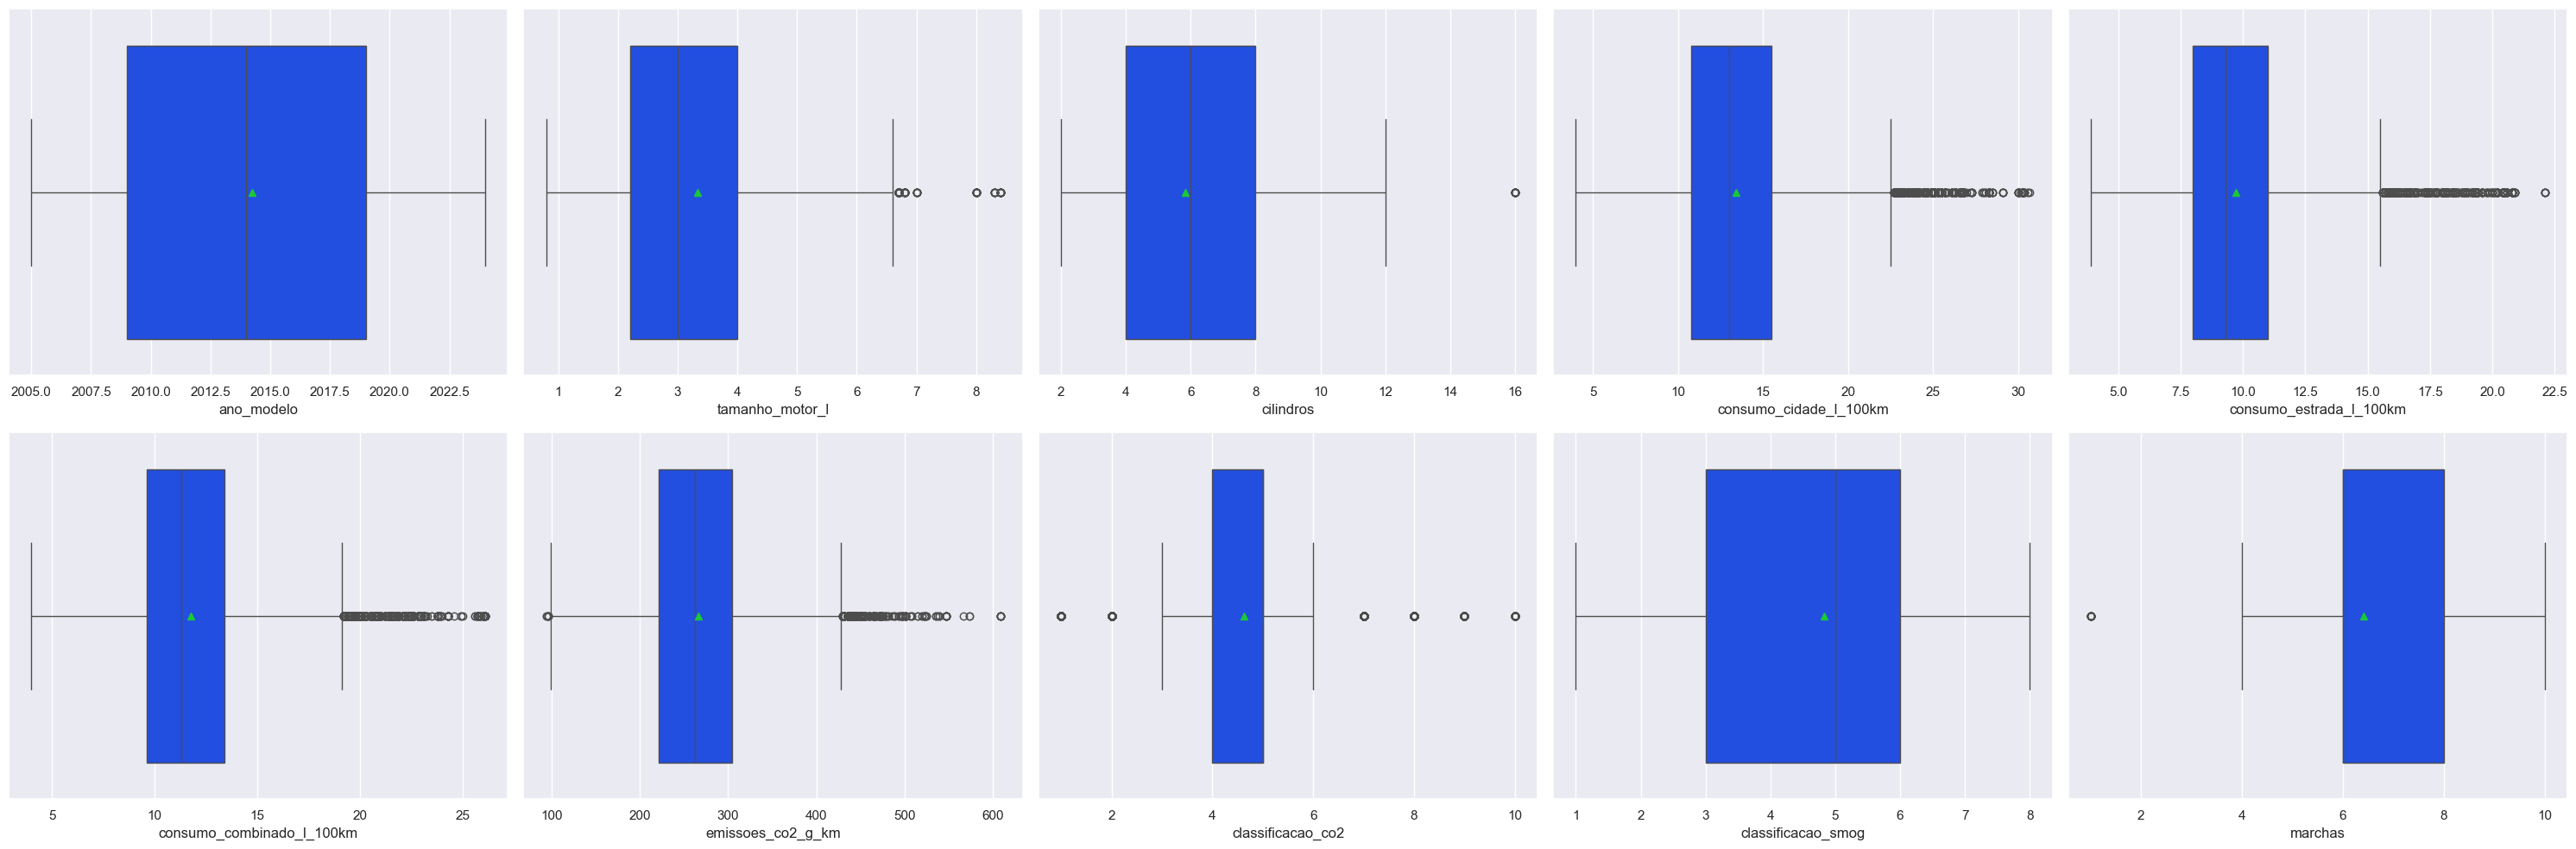

In [17]:
fig, axs = plt.subplots(2, 5, figsize=(30, 10))

for ax, coluna in zip(axs.flatten(), df.select_dtypes("number").columns):
    sns.boxplot(data=df, x=coluna, ax=ax, showmeans=True)

plt.tight_layout()
plt.show()

#### Verificando a correlação atrvés de um mapa de calor

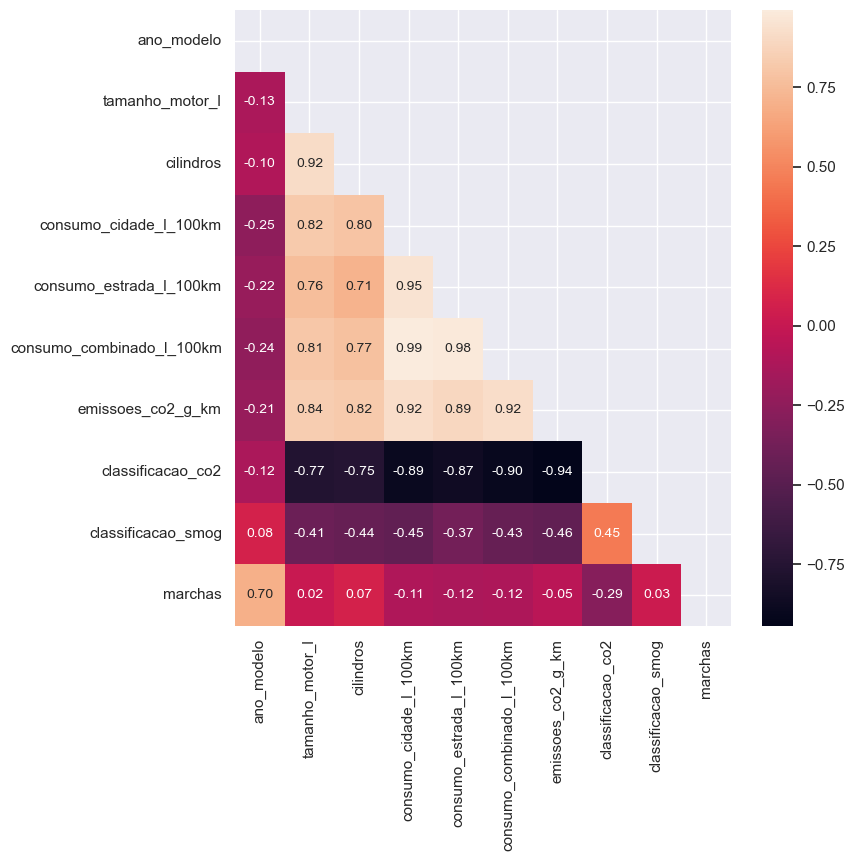

In [18]:
corr = df.select_dtypes("number").corr()
matriz = np.triu(corr)

fig, ax = plt.subplots(figsize=(8,8))

sns.heatmap(corr, ax=ax, mask=matriz, annot=True, fmt=".2f", annot_kws={"fontsize": 10})

plt.show()

#### Criando gráficos de barras para verificar o nível de CO$_2$ emitido por algumas colunas

Colunas:
 
- marca         
- classe_veiculo         
- tipo_combustivel      
- ano_modelo

In [19]:
co2_latex = r"CO$_2$"
norm = mcolors.Normalize(vmin=df["emissoes_co2_g_km"].min(), vmax=df["emissoes_co2_g_km"].max())
cmap = cm.RdYlGn_r

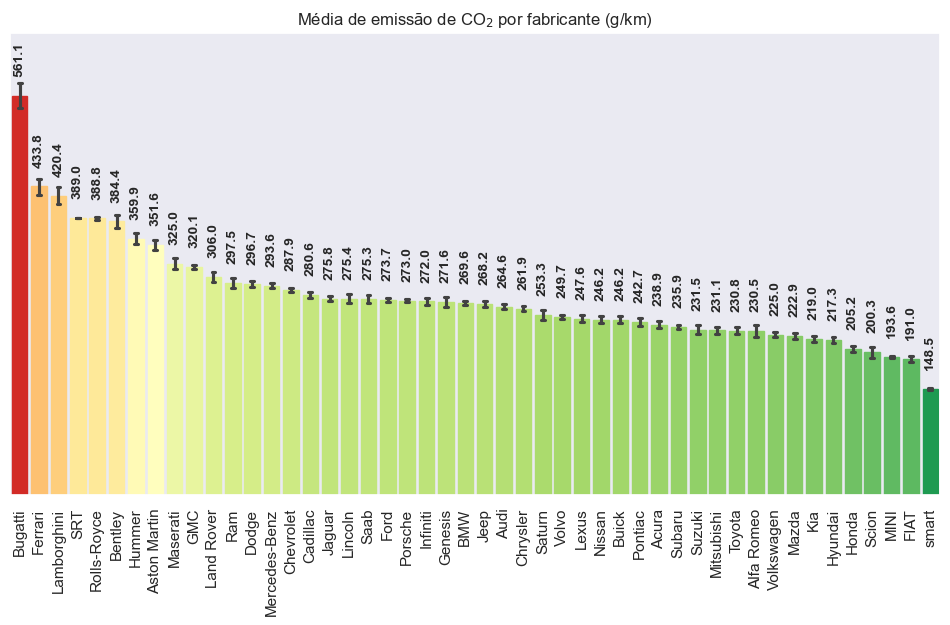

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(data=df, x="marca", y="emissoes_co2_g_km", ax=ax, order=df.groupby("marca")["emissoes_co2_g_km"].mean().sort_values(ascending=False).index,
            capsize=0.2)

ax.bar_label(ax.containers[0], fmt="%.1f", rotation=90, padding=14, size=10, weight="bold")

ax.set_ylim(0, 650)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_yticks([])
plt.xticks(rotation=90)

ax.set_title(f"Média de emissão de {co2_latex} por fabricante (g/km)")

for barra in ax.patches:
    barra.set_color(cmap(norm(barra.get_height())))

plt.show()

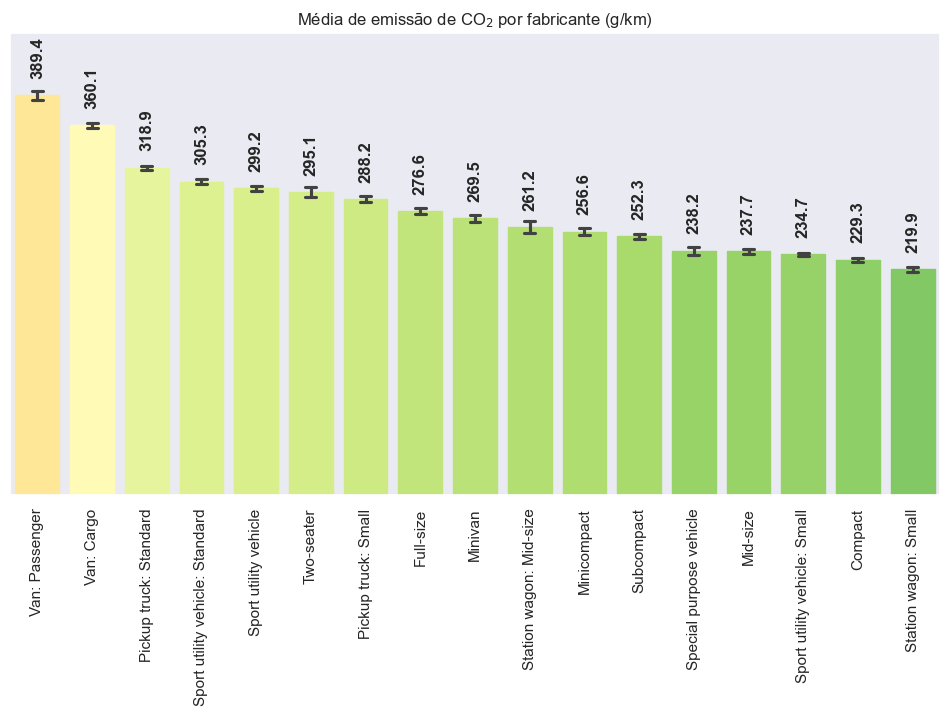

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(data=df, x="classe_veiculo", y="emissoes_co2_g_km", ax=ax,
            order=df.groupby("classe_veiculo")["emissoes_co2_g_km"].mean().sort_values(ascending=False).index,capsize=0.2)

ax.bar_label(ax.containers[0], fmt="%.1f", rotation=90, padding=12, size=12, weight="bold")

ax.set_ylim(0, 450)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_yticks([])
plt.xticks(rotation=90)

ax.set_title(f"Média de emissão de {co2_latex} por fabricante (g/km)")

norm = mcolors.Normalize(vmin=df["emissoes_co2_g_km"].min(), vmax=df["emissoes_co2_g_km"].max())
cmap = cm.RdYlGn_r

for barra in ax.patches:
    barra.set_color(cmap(norm(barra.get_height())))

plt.show()

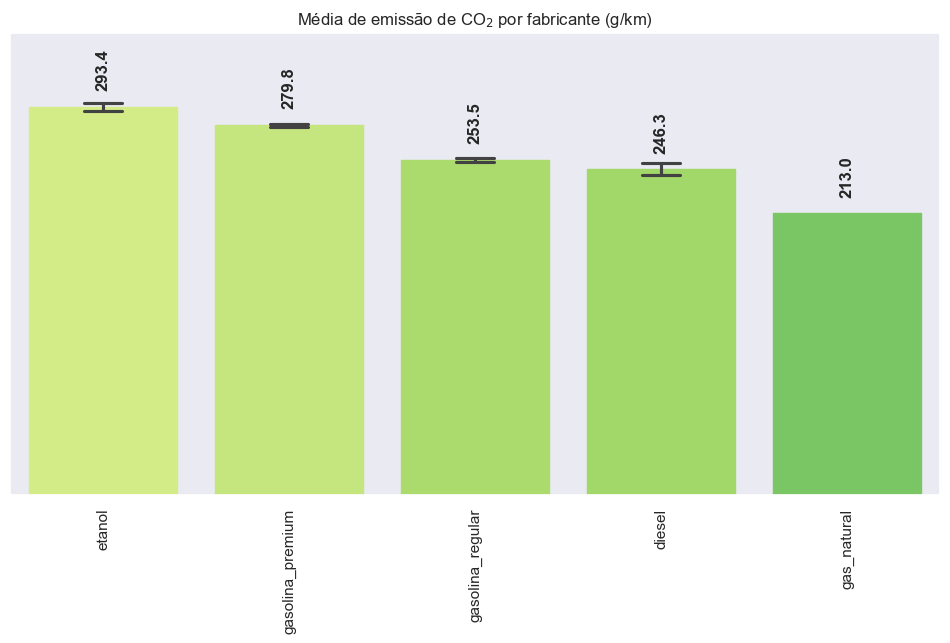

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(data=df, x="tipo_combustivel", y="emissoes_co2_g_km", ax=ax,
            order=df.groupby("tipo_combustivel")["emissoes_co2_g_km"].mean().sort_values(ascending=False).index,capsize=0.2)

ax.bar_label(ax.containers[0], fmt="%.1f", rotation=90, padding=12, size=12, weight="bold")

ax.set_ylim(0, 350)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_yticks([])
plt.xticks(rotation=90)

ax.set_title(f"Média de emissão de {co2_latex} por fabricante (g/km)")

norm = mcolors.Normalize(vmin=df["emissoes_co2_g_km"].min(), vmax=df["emissoes_co2_g_km"].max())
cmap = cm.RdYlGn_r

for barra in ax.patches:
    barra.set_color(cmap(norm(barra.get_height())))

plt.show()

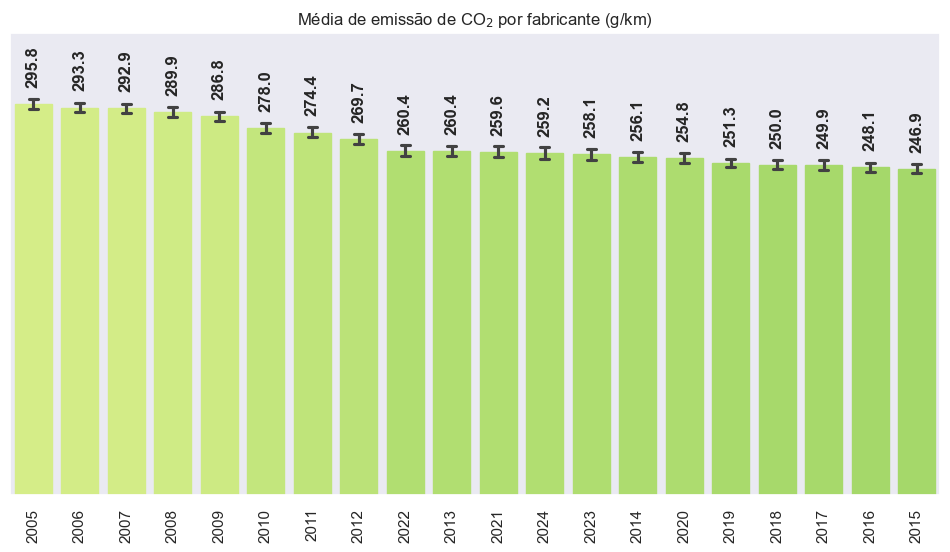

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(data=df, x="ano_modelo", y="emissoes_co2_g_km", ax=ax,
            order=df.groupby("ano_modelo")["emissoes_co2_g_km"].mean().sort_values(ascending=False).index,capsize=0.2)

ax.bar_label(ax.containers[0], fmt="%.1f", rotation=90, padding=12, size=12, weight="bold")

ax.set_ylim(0, 350)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_yticks([])
plt.xticks(rotation=90)

ax.set_title(f"Média de emissão de {co2_latex} por fabricante (g/km)")

norm = mcolors.Normalize(vmin=df["emissoes_co2_g_km"].min(), vmax=df["emissoes_co2_g_km"].max())
cmap = cm.RdYlGn_r

for barra in ax.patches:
    barra.set_color(cmap(norm(barra.get_height())))

plt.show()

#### Verificando a frequência de algumas combinações com crosstab

In [24]:
pd.crosstab(df["ano_modelo"], df["classe_veiculo"])

classe_veiculo,Compact,Full-size,Mid-size,Minicompact,Minivan,Pickup truck: Small,Pickup truck: Standard,Special purpose vehicle,Sport utility vehicle,Sport utility vehicle: Small,Sport utility vehicle: Standard,Station wagon: Mid-size,Station wagon: Small,Subcompact,Two-seater,Van: Cargo,Van: Passenger
ano_modelo,,,,,,,,,,,,,,,,,
2005,146,45,114,74,33,0,127,0,224,0,0,38,54,87,52,13,12
2006,137,56,111,37,35,0,141,0,221,0,0,28,53,78,49,14,8
2007,116,54,139,47,34,0,154,0,240,0,0,32,44,83,61,27,12
2008,148,63,134,49,22,52,72,0,267,0,0,18,43,100,73,26,12
2009,152,68,125,43,16,59,95,0,268,0,0,13,56,99,64,26,12
2010,144,77,120,41,14,54,73,1,251,0,0,9,63,98,59,18,8
2011,128,71,132,53,14,51,85,1,270,0,0,4,59,104,64,22,27
2012,137,81,132,76,16,43,79,2,239,0,0,5,50,102,76,22,31
2013,175,77,157,53,15,12,84,5,0,139,109,3,47,96,58,22,30


In [25]:
pd.crosstab(df["ano_modelo"], df["tipo_combustivel"])

tipo_combustivel,diesel,etanol,gas_natural,gasolina_premium,gasolina_regular
ano_modelo,,,,,
2005,14,30,0,432,543
2006,12,23,0,389,544
2007,5,53,0,429,556
2008,5,48,0,480,546
2009,10,71,0,439,576
2010,14,71,0,408,537
2011,15,104,0,421,545
2012,16,104,0,432,539
2013,19,110,0,429,524


Como gás natural só possui 1 registro, ela é irrelevante para a análise e pode ser apagada

In [26]:
df = df.drop(df[df["tipo_combustivel"] == "gas_natural"].index)

In [27]:
pd.crosstab(df["ano_modelo"], df["tipo_combustivel"]).style.background_gradient(cmap="coolwarm")

tipo_combustivel,diesel,etanol,gasolina_premium,gasolina_regular
ano_modelo,,,,
2005,14,30,432,543
2006,12,23,389,544
2007,5,53,429,556
2008,5,48,480,546
2009,10,71,439,576
2010,14,71,408,537
2011,15,104,421,545
2012,16,104,432,539
2013,19,110,429,524


In [28]:
pd.crosstab(df["ano_modelo"], df["tipo_combustivel"], values=df["emissoes_co2_g_km"], aggfunc="mean").style.background_gradient(cmap="coolwarm", axis=None)

tipo_combustivel,diesel,etanol,gasolina_premium,gasolina_regular
ano_modelo,,,,
2005,215.000000,338.666667,299.574074,292.445672
2006,196.750000,330.826087,297.133676,291.117647
2007,297.400000,318.113208,296.916084,287.377698
2008,300.200000,310.083333,297.243750,281.556777
2009,251.300000,297.070423,301.733485,274.781250
2010,248.214286,297.507042,298.546569,260.620112
2011,247.266667,300.288462,286.159145,261.179817
2012,244.187500,301.125000,280.636574,255.552876
2013,236.684211,296.372727,270.165501,245.748092


#### Verificando a distribuição dos dados de "consumo_cidade_l_100km" e "consumo_estrada_l_100km" através de histograma e kde

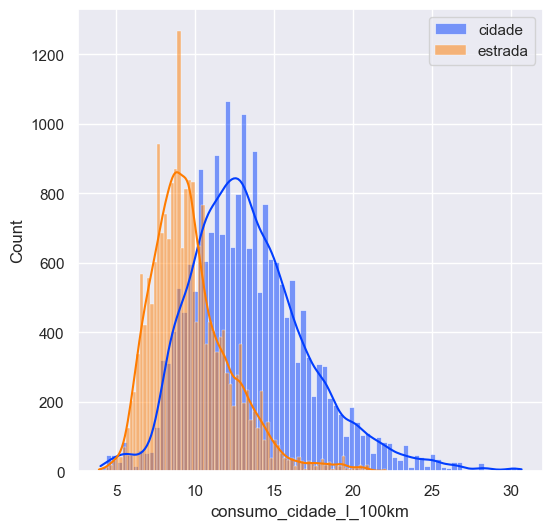

In [29]:
fig, ax = plt.subplots(figsize=(6, 6))

sns.histplot(data=df, x="consumo_cidade_l_100km", kde=True, ax=ax, label="cidade")
sns.histplot(data=df, x="consumo_estrada_l_100km", kde=True, ax=ax, label="estrada")

plt.legend()
plt.show()

- faça um gráfico de dispersão de combined_l_100_km por co2_emissions_g_km, usando o tipo de combustível como hue

#### Analisando a relação e o grau de correlação entre "consumo_combinado_l_100km" e "emissoes_co2_g_km" por meio de um gráfico de dispersão

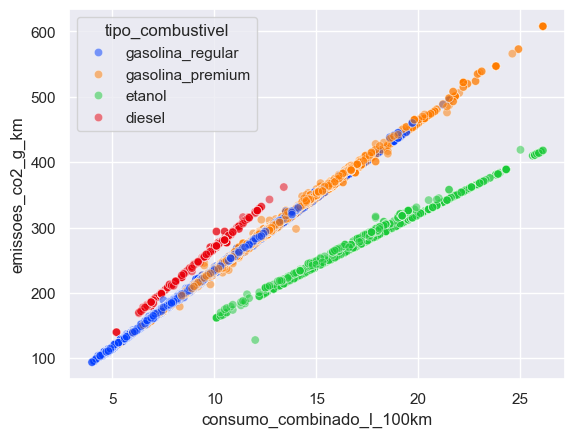

In [30]:
fig, ax = plt.subplots()

sns.scatterplot(data=df, x="consumo_combinado_l_100km", y="emissoes_co2_g_km", ax=ax, hue="tipo_combustivel", alpha=0.5)

plt.show()

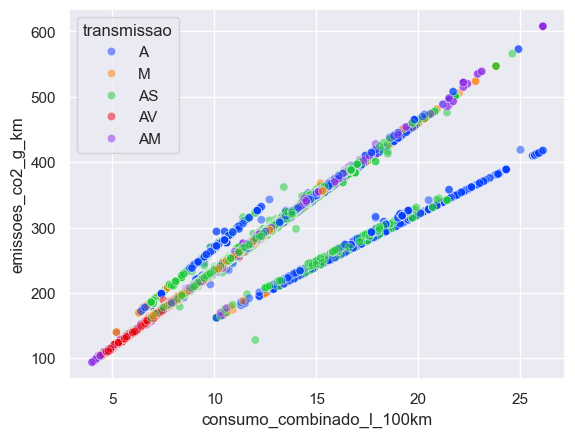

In [31]:
fig, ax = plt.subplots()

sns.scatterplot(data=df, x="consumo_combinado_l_100km", y="emissoes_co2_g_km", ax=ax, hue="transmissao", alpha=0.5)

plt.show()

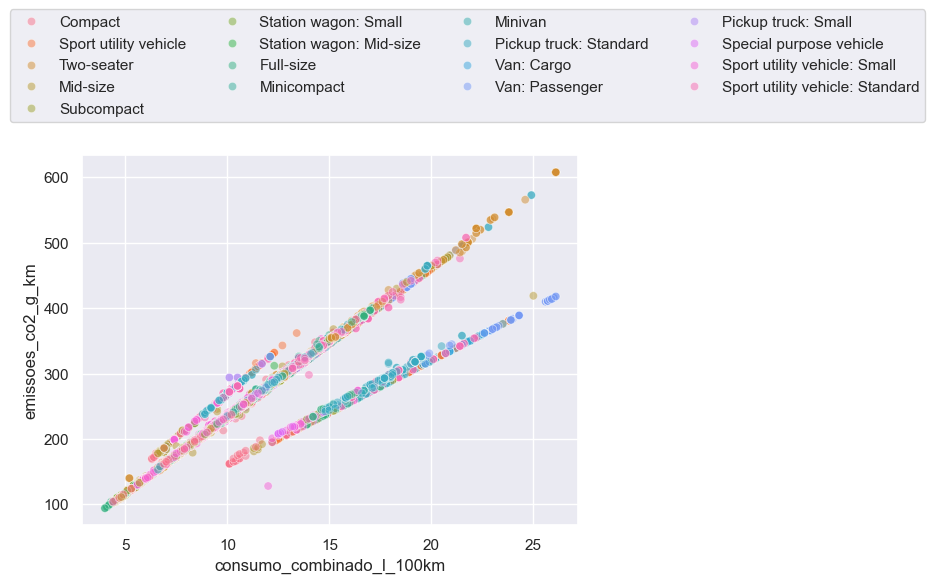

In [32]:
fig, ax = plt.subplots()

sns.scatterplot(data=df, x="consumo_combinado_l_100km", y="emissoes_co2_g_km", ax=ax, hue="classe_veiculo", alpha=0.5)

ax.legend(loc="upper left", bbox_to_anchor=(0, 1.2), ncol=4, bbox_transform=fig.transFigure)
plt.show()

#### Analisando a relação e o grau de correlação entre "cilindros" e "emissoes_co2_g_km" por meio de um gráfico de dispersão

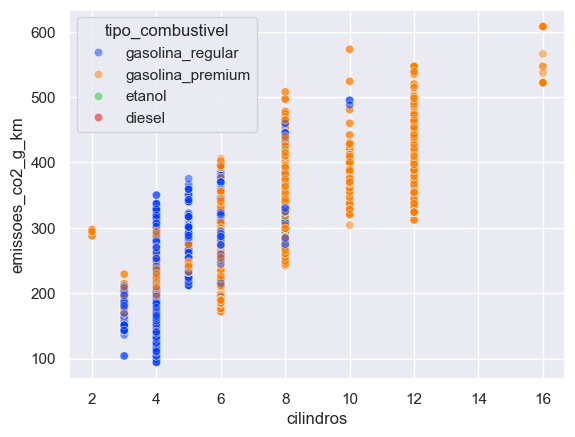

In [33]:
fig, ax = plt.subplots()

sns.scatterplot(data=df, x="cilindros", y="emissoes_co2_g_km", ax=ax, hue="tipo_combustivel", alpha=0.5)

plt.show()

#### Criando uma nova coluna "classe_de_veículo_agrupada" para agrupar os tipos de carros

In [34]:
class_map = {
    "Two-seater": "carro",
    "Minicompact": "carro",
    "Subcompact": "carro",
    "Compact": "carro",
    "Mid-size": "carro",
    "Full-size": "carro",
    "Station wagon: Small": "perua",
    "Station wagon: Mid-size": "perua",
    "Pickup truck: Small": "picape",
    "Pickup truck: Standard": "picape",
    "Sport utility vehicle": "suv",
    "Sport utility vehicle: Small": "suv",
    "Sport utility vehicle: Standard": "suv",
    "Minivan": "van",
    "Van: Cargo": "van",
    "Van: Passenger": "van",
    "Special purpose vehicle": "veículo_finalidade_específica",
}

df["classe_veiculo_agrupada"] = df["classe_veiculo"].map(class_map)

df["classe_veiculo_agrupada"].value_counts(dropna=False)

classe_veiculo_agrupada
carro                            10719
suv                               5568
picape                            2347
perua                             1025
van                                742
veículo_finalidade_específica      119
Name: count, dtype: int64

#### Verificando a distribuição das colunas anteriores em relação à coluna "classe_veiculo_agrupada"

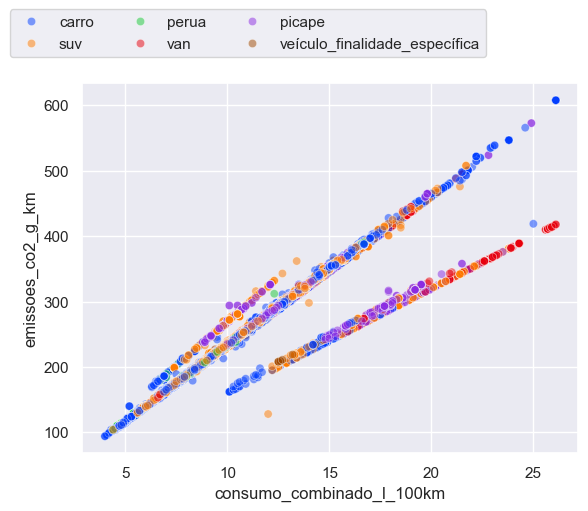

In [35]:
fig, ax = plt.subplots()

sns.scatterplot(data=df, x="consumo_combinado_l_100km", y="emissoes_co2_g_km", ax=ax, hue="classe_veiculo_agrupada", alpha=0.5)

ax.legend(loc="upper left", bbox_to_anchor=(0, 1.05), ncol=3, bbox_transform=fig.transFigure)
plt.show()

#### Verificando a frequência de "classe_veiculo_agrupada" em relação à "tipo_combustivel"

In [36]:
pd.crosstab(df["classe_veiculo_agrupada"], df["tipo_combustivel"])

tipo_combustivel,diesel,etanol,gasolina_premium,gasolina_regular
classe_veiculo_agrupada,,,,
carro,104,197,6669,3749
perua,28,1,446,550
picape,102,330,117,1798
suv,135,294,1682,3457
van,0,197,3,542
veículo_finalidade_específica,0,15,21,83


#### Algumas colunas são desnecessárias para o restante do projeto, então podem ser eliminadas

Colunas:

- marca
- classificacao_co2
- classificacao_smog
- marchas
- classe_veiculo

In [37]:
df = df.drop(columns=["marca", "classificacao_co2", "classificacao_smog", "marchas", "classe_veiculo"])

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20520 entries, 0 to 20520
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ano_modelo                 20520 non-null  int64  
 1   tamanho_motor_l            20520 non-null  float64
 2   cilindros                  20520 non-null  int64  
 3   transmissao                20520 non-null  object 
 4   tipo_combustivel           20520 non-null  object 
 5   consumo_cidade_l_100km     20520 non-null  float64
 6   consumo_estrada_l_100km    20520 non-null  float64
 7   consumo_combinado_l_100km  20520 non-null  float64
 8   emissoes_co2_g_km          20520 non-null  int64  
 9   classe_veiculo_agrupada    20520 non-null  object 
dtypes: float64(4), int64(3), object(3)
memory usage: 1.7+ MB


### Comparando todas as colunas númericas, usando o pairplot

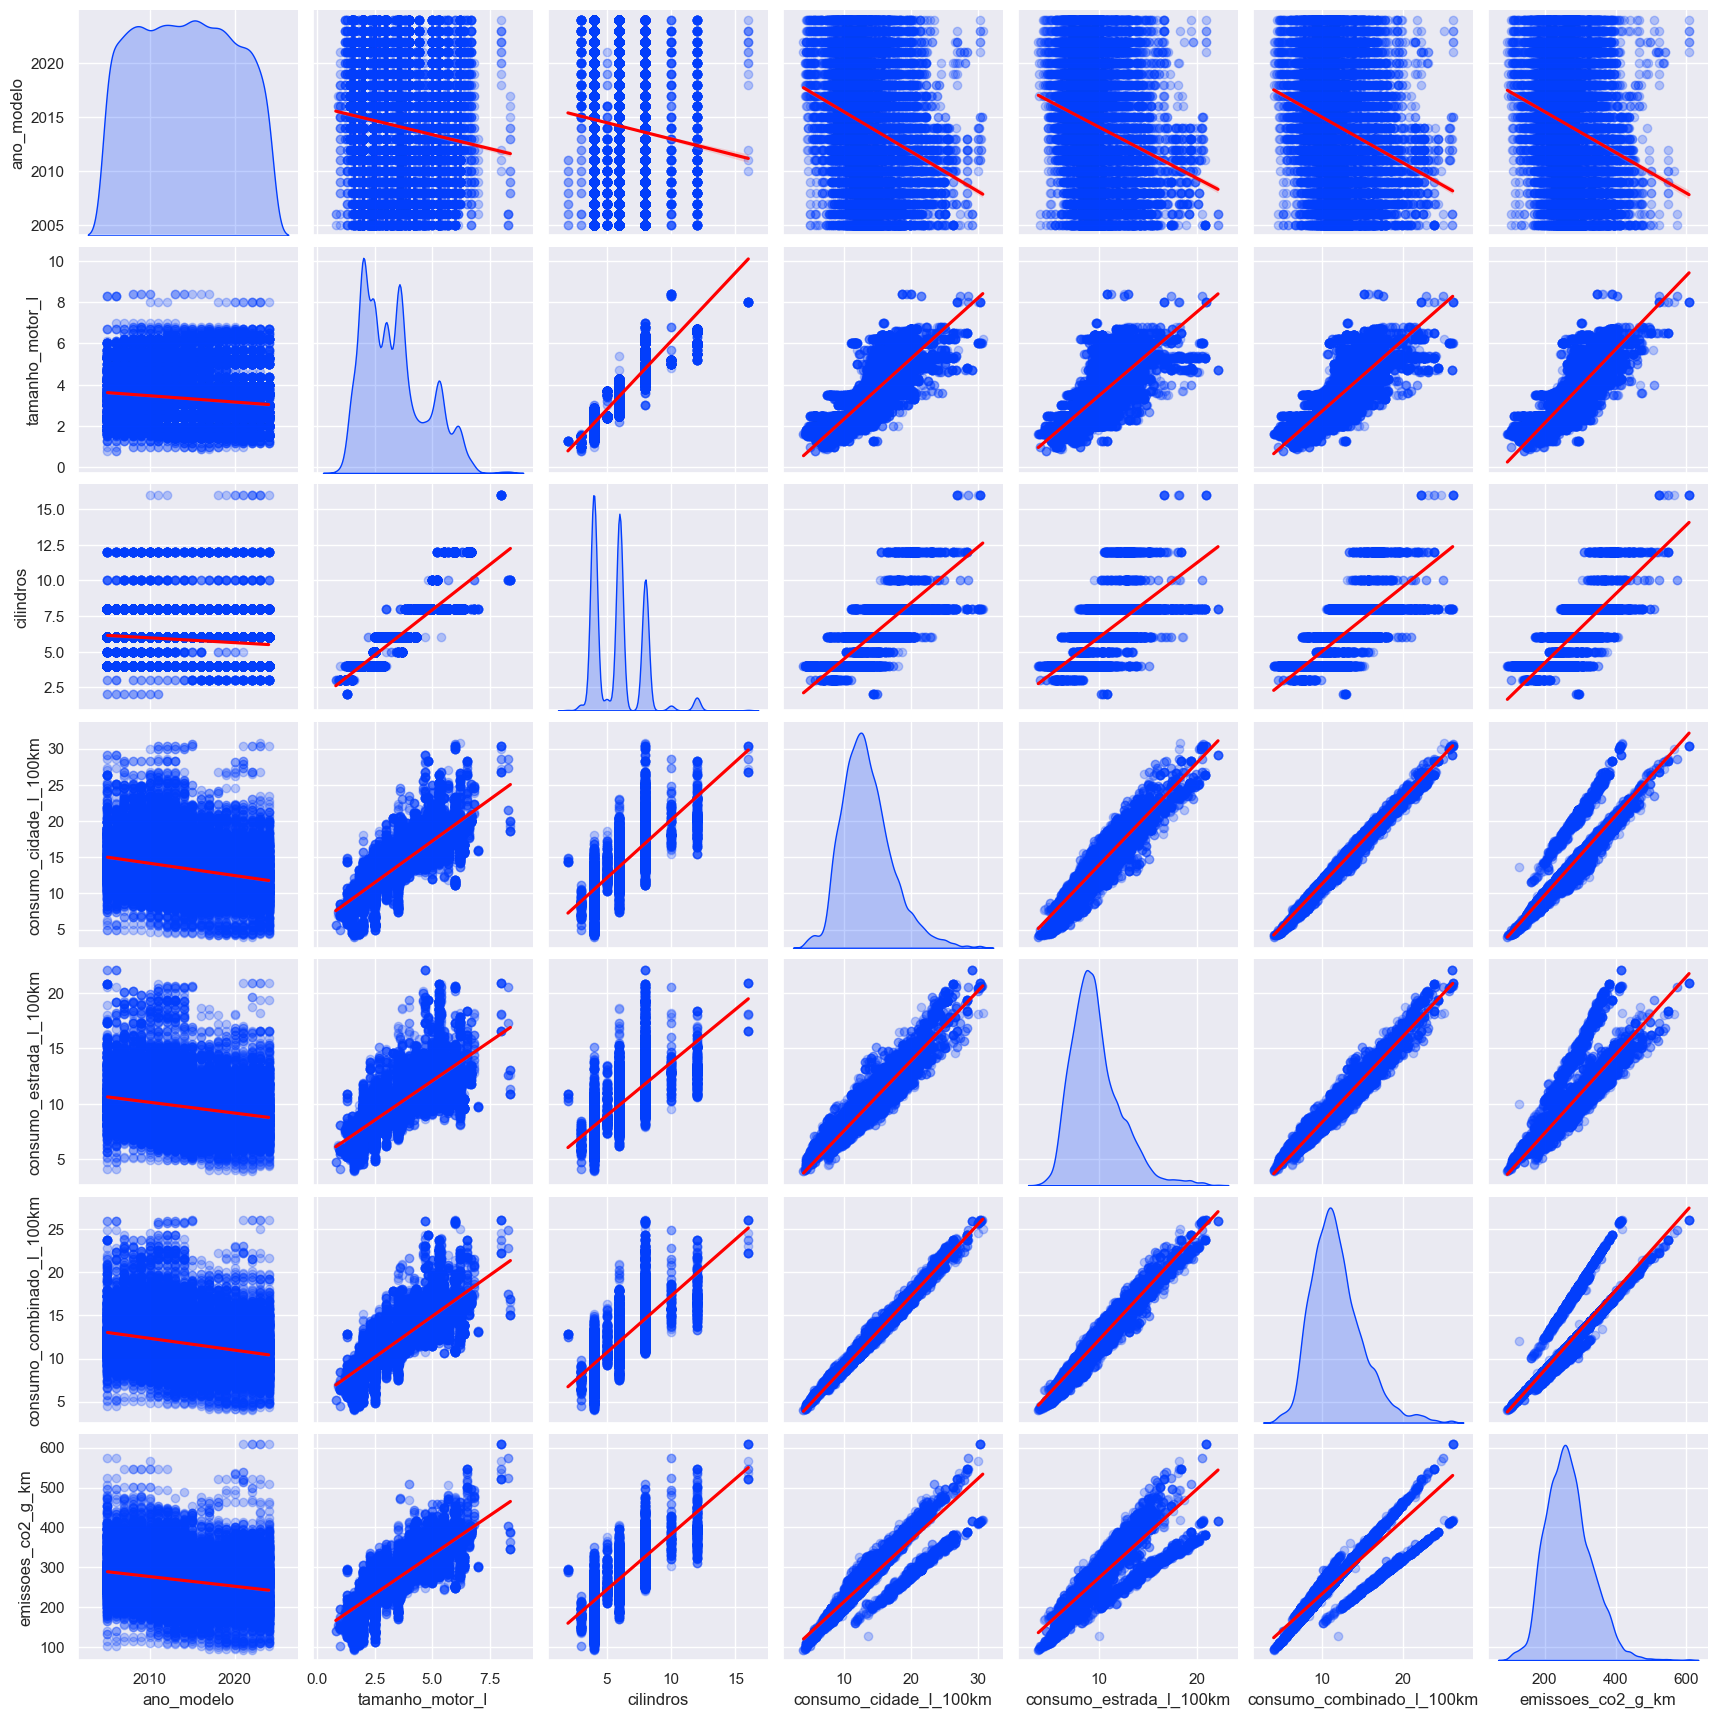

In [39]:
sns.pairplot(df, kind="reg", diag_kind="kde", plot_kws={"line_kws": {"color": "red"}, "scatter_kws": {"alpha": 0.25}})

Com o pairplot, podemos notar que a coluna de "tamanho_motor_l" possui uma distribuição muito irregular, então podemos criar classificações com o tamanho dos valores

In [40]:
df["tamanho_motor_l"].value_counts()

tamanho_motor_l
2.0    3142
3.0    2062
3.5    1420
2.5    1407
3.6    1194
       ... 
2.1       5
2.6       4
0.8       3
0.9       3
5.8       2
Name: count, Length: 61, dtype: int64

In [41]:
df["tamanho_motor_l"].value_counts(bins=4).sort_index()

(0.791, 2.7]    8365
(2.7, 4.6]      8042
(4.6, 6.5]      3920
(6.5, 8.4]       193
Name: count, dtype: int64

In [42]:
df["tamanho_motor_l_classe"] = pd.cut(df["tamanho_motor_l"], bins=[-np.inf, 2.0, 4.0, 6.0, np.inf],
                                      labels=["up_to_2", "up_to_4", "up_to_6", "more_than_6"])

df["tamanho_motor_l_classe"].value_counts().sort_index()

tamanho_motor_l_classe
up_to_2         5104
up_to_4        10327
up_to_6         4264
more_than_6      825
Name: count, dtype: int64

O mesmo pode ser feito com a coluna "cilindros", que apresenta um comportamento parecido

In [43]:
df["cilindros"].value_counts()

cilindros
4     7678
6     6950
8     4645
12     455
5      396
3      198
10     168
16      16
2       14
Name: count, dtype: int64

In [44]:
df["cilindros"].value_counts(bins=4).sort_index()

(1.985, 5.5]     8286
(5.5, 9.0]      11595
(9.0, 12.5]       623
(12.5, 16.0]       16
Name: count, dtype: int64

In [45]:
df["cilindros_classe"] = pd.cut(df["cilindros"], bins=[-np.inf, 4, 6, 8, np.inf], labels=["up_to_4", "up_to_6", "up_to_8", "more_than_8"])

df["cilindros_classe"].value_counts().sort_index()

cilindros_classe
up_to_4        7890
up_to_6        7346
up_to_8        4645
more_than_8     639
Name: count, dtype: int64

Com isso feito, podemos eliminar as colunas de "tamanho_motor_l" e "cilindros"

In [46]:
df = df.drop(columns=["tamanho_motor_l", "cilindros"])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20520 entries, 0 to 20520
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   ano_modelo                 20520 non-null  int64   
 1   transmissao                20520 non-null  object  
 2   tipo_combustivel           20520 non-null  object  
 3   consumo_cidade_l_100km     20520 non-null  float64 
 4   consumo_estrada_l_100km    20520 non-null  float64 
 5   consumo_combinado_l_100km  20520 non-null  float64 
 6   emissoes_co2_g_km          20520 non-null  int64   
 7   classe_veiculo_agrupada    20520 non-null  object  
 8   tamanho_motor_l_classe     20520 non-null  category
 9   cilindros_classe           20520 non-null  category
dtypes: category(2), float64(3), int64(2), object(3)
memory usage: 1.4+ MB


In [47]:
df.to_parquet(DADOS_TRATADOS, index=False)